In [1]:
import anndata as ad
import torch
import pytorch_lightning as pl  # pyright: ignore[reportMissingImports]
from src.dataset import ScDataModule
from src.ae import LightningAE
import scanpy as sc  # pyright: ignore[reportMissingImports]
import os
import numpy as np
from src.utils import compare_umap


adata = ad.read_h5ad('data/Alles_filtered.h5ad')
adata.var_names_make_unique()
display(adata.X)
display(adata.obs)

sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

adatamodule = ScDataModule(adata, "cell_type1", "LabelEncoder")
ae_model = LightningAE(n_genes=adata.X.shape[1])

trainer = pl.Trainer(
    max_epochs=50,
    accelerator="auto",
    devices="auto",
    log_every_n_steps=50,
    enable_checkpointing=True,
    logger=True,
    default_root_dir="lightning_logs/ae"
)

ae_model_path = "checkpoints/trained_ae_model.ckpt"
if os.path.exists(ae_model_path):
    # read the model from the checkpoint
    ae_model = LightningAE.load_from_checkpoint("checkpoints/trained_ae_model.ckpt")
else:
    trainer.fit(ae_model, adatamodule)
    trainer.save_checkpoint(ae_model_path)
    
X_dense = adata.X.toarray()

# Convert to torch tensor and move to same device as model
device = next(ae_model.parameters()).device
X_tensor = torch.tensor(X_dense, dtype=torch.float32).to(device)




/opt/miniconda3/envs/lightning/lib/python3.12/site-packages/tqdm/auto.py:21: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 5236395 stored elements and shape (4614, 11835)>

,cell_type1,data_type,cell_ontology_class,n_genes,n_counts
cell_id,,,,,
ACTTAGCGTTTN,undifferentiated cells,raw,nan,1588,5416
ATACACCCGCCC,undifferentiated cells,raw,nan,1165,4032
TCGGCGATGTAT,undifferentiated cells,raw,nan,1134,3992
GTTCGCCGTCGA,undifferentiated cells,raw,nan,1706,8109
CTAATCGCTAGT,undifferentiated cells,raw,nan,810,2743
...,...,...,...,...,...
TTTTAAGACGGN,LVM longitudinal visc. muscle,raw,visceral muscle cell,1027,3737
TCTTCACGAAGA,LVM longitudinal visc. muscle,raw,visceral muscle cell,1548,5824
GTTGCAATGGAG,LVM longitudinal visc. muscle,raw,visceral muscle cell,1136,3099


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name      | Type    | Params | Mode 
----------------------------------------------
0 | encoder   | Encoder | 14.4 M | train
1 | decoder   | Decoder | 14.4 M | train
2 | criterion | MSELoss | 0      | train
----------------------------------------------
28.7 M    Trainable params
0         Non-trainable params
28.7 M    Total params
114.900   Total estimated model params size (MB)
39        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/opt/miniconda3/envs/lightning/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:433: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.


/opt/miniconda3/envs/lightning/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:433: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.
/opt/miniconda3/envs/lightning/lib/python3.12/site-packages/pytorch_lightning/loops/fit_loop.py:310: The number of training batches (29) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Epoch 49: 100%|██████████| 29/29 [00:01<00:00, 25.87it/s, v_num=0, val_loss=0.123, train_loss=0.115]

`Trainer.fit` stopped: `max_epochs=50` reached.


Epoch 49: 100%|██████████| 29/29 [00:01<00:00, 18.45it/s, v_num=0, val_loss=0.123, train_loss=0.115]


In [ ]:
from src.lightning_diffusion import LightningDiffusion
ae_model.eval()
with torch.no_grad():
    latent = ae_model.encode(X_tensor).cpu().numpy()  # shape [n_cells, latent_dim]

# standardize the latent space
latent = (latent - latent.mean(axis=0)) / latent.std(axis=0)
latent_adata = ad.AnnData(latent, obs=adata.obs.copy())

latent_dm = ScDataModule(latent_adata, label_key="cell_type1",
                        encoder="LabelEncoder", batch_size=128, val_split=0.1)
latent_dm.setup()

dim = latent.shape[1]
num_classes = int(latent_dm.train_dataset.dataset.classes.max()) + 1

diffusion = LightningDiffusion(
    input_dim=dim,
    num_classes=num_classes
)

trainer = pl.Trainer(
    max_epochs=100,
    accelerator="auto",
    devices="auto",
    log_every_n_steps=50,
    enable_checkpointing=True,
    logger=True,
    default_root_dir="lightning_logs/diffusion"
)

diffusion_model_path = "checkpoints/trained_diffusion_model.ckpt"
if os.path.exists(diffusion_model_path):
    diffusion = LightningDiffusion.load_from_checkpoint(diffusion_model_path)
else:
    trainer.fit(diffusion, latent_dm)
    trainer.save_checkpoint(diffusion_model_path)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name      | Type              | Params | Mode 
--------------------------------------------------------
0 | model     | DenoisingUNet     | 7.2 M  | train
1 | diffusion | GaussianDiffusion | 7.2 M  | train
--------------------------------------------------------
7.2 M     Trainable params
0         Non-trainable params
7.2 M     Total params
28.693    Total estimated model params size (MB)
92        Modules in train mode
0         Modules in eval mode


/opt/miniconda3/envs/lightning/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:433: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.
/opt/miniconda3/envs/lightning/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:433: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.
/opt/miniconda3/envs/lightning/lib/python3.12/site-packages/pytorch_lightning/loops/fit_loop.py:310: The number of training batches (33) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Epoch 99: 100%|██████████| 33/33 [00:00<00:00, 55.10it/s, v_num=0, val_loss=0.332, train_loss=0.305]

`Trainer.fit` stopped: `max_epochs=100` reached.


Epoch 99: 100%|██████████| 33/33 [00:00<00:00, 45.50it/s, v_num=0, val_loss=0.332, train_loss=0.305]


In [3]:
latent_adata.obs

,cell_type1,data_type,cell_ontology_class,n_genes,n_counts
cell_id,,,,,
ACTTAGCGTTTN,undifferentiated cells,raw,nan,1588,5416
ATACACCCGCCC,undifferentiated cells,raw,nan,1165,4032
TCGGCGATGTAT,undifferentiated cells,raw,nan,1134,3992
GTTCGCCGTCGA,undifferentiated cells,raw,nan,1706,8109
CTAATCGCTAGT,undifferentiated cells,raw,nan,810,2743
...,...,...,...,...,...
TTTTAAGACGGN,LVM longitudinal visc. muscle,raw,visceral muscle cell,1027,3737
TCTTCACGAAGA,LVM longitudinal visc. muscle,raw,visceral muscle cell,1548,5824
GTTGCAATGGAG,LVM longitudinal visc. muscle,raw,visceral muscle cell,1136,3099


In [4]:
real_labels = latent_dm.train_dataset.dataset.classes
device = next(diffusion.parameters()).device
labels_tensor = torch.tensor(real_labels, dtype=torch.long).to(device)

if os.path.exists("data/latent_samples.pt"):
    latent_samples = torch.load("data/latent_samples.pt")
else:
    latent_samples = diffusion.sample(num_samples=len(latent_adata),
                                    labels=labels_tensor)
    torch.save(latent_samples, "data/latent_samples.pt")
    
with torch.no_grad():
    recon = ae_model.decode(latent_samples.to(device))

sampling loop time step: 100%|██████████| 1000/1000 [13:20<00:00,  1.25it/s]


Performing UMAP on combined dataset (9228 samples, 128 features)...


/opt/miniconda3/envs/lightning/lib/python3.12/site-packages/umap/umap_.py:1952: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.


UMAP completed. Generating visualizations...


(array([[ 9.219721 ,  7.6488214],
        [11.595671 ,  8.034254 ],
        [10.914731 ,  9.08202  ],
        ...,
        [10.113091 ,  7.6549077],
        [ 6.547482 , 11.20244  ],
        [ 8.941001 , 11.940935 ]], shape=(4614, 2), dtype=float32),
 array([[ 6.872103 ,  6.243575 ],
        [ 9.949719 , 10.334156 ],
        [10.665734 ,  9.874562 ],
        ...,
        [ 9.717441 ,  8.001011 ],
        [10.524745 , 10.880931 ],
        [ 7.8750052,  8.105413 ]], shape=(4614, 2), dtype=float32),
 <Figure size 1400x600 with 2 Axes>)

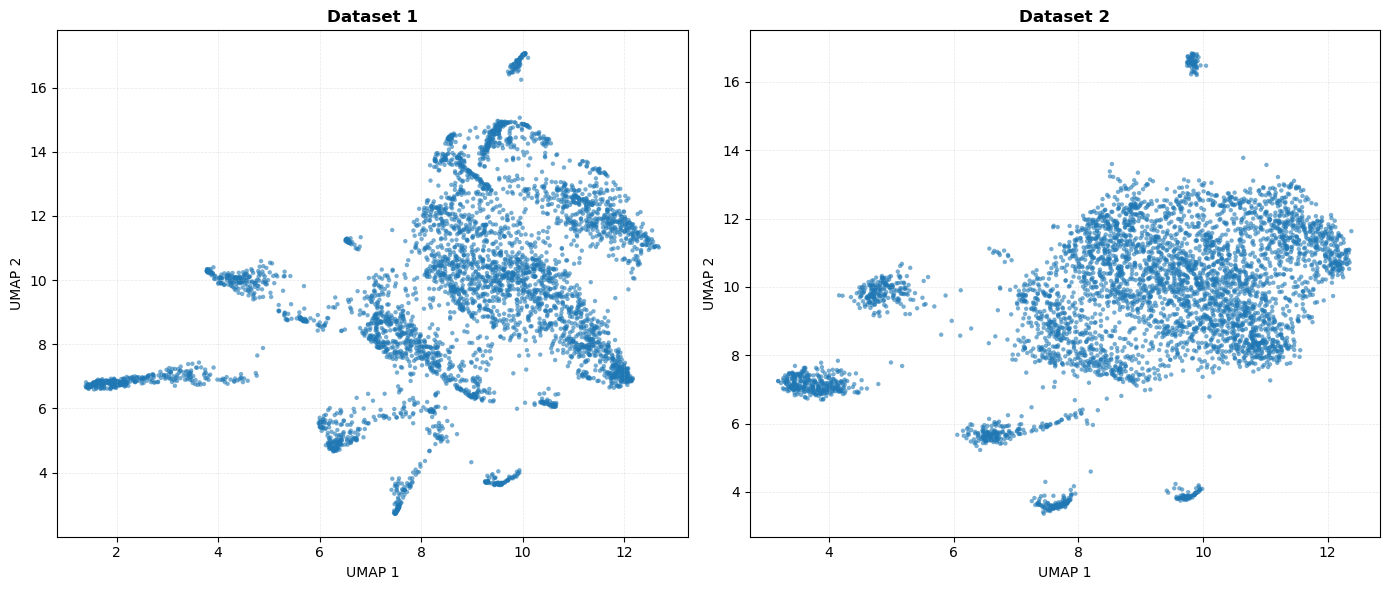

In [5]:
compare_umap(latent_adata.X, latent_samples)

  Class 0: 47 (1.0%)
  Class 1: 199 (4.3%)
  Class 2: 650 (14.1%)
  Class 3: 221 (4.8%)
  Class 4: 82 (1.8%)
  Class 5: 82 (1.8%)
  Class 6: 339 (7.3%)
  Class 7: 107 (2.3%)
  Class 8: 308 (6.7%)
  Class 9: 545 (11.8%)
  Class 10: 155 (3.4%)
  Class 11: 1512 (32.8%)
  Class 12: 248 (5.4%)
  Class 13: 119 (2.6%)


sampling loop time step: 100%|██████████| 1000/1000 [16:58<00:00,  1.02s/it]
/opt/miniconda3/envs/lightning/lib/python3.12/site-packages/umap/umap_.py:1952: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



生成数据类别分布:
  Class 0: 47 (1.0%)
  Class 1: 199 (4.3%)
  Class 2: 650 (14.1%)
  Class 3: 221 (4.8%)
  Class 4: 82 (1.8%)
  Class 5: 82 (1.8%)
  Class 6: 339 (7.3%)
  Class 7: 107 (2.3%)
  Class 8: 308 (6.7%)
  Class 9: 545 (11.8%)
  Class 10: 155 (3.4%)
  Class 11: 1512 (32.8%)
  Class 12: 248 (5.4%)
  Class 13: 119 (2.6%)
Performing UMAP on combined dataset (9228 samples, 128 features)...
UMAP completed. Generating visualizations...


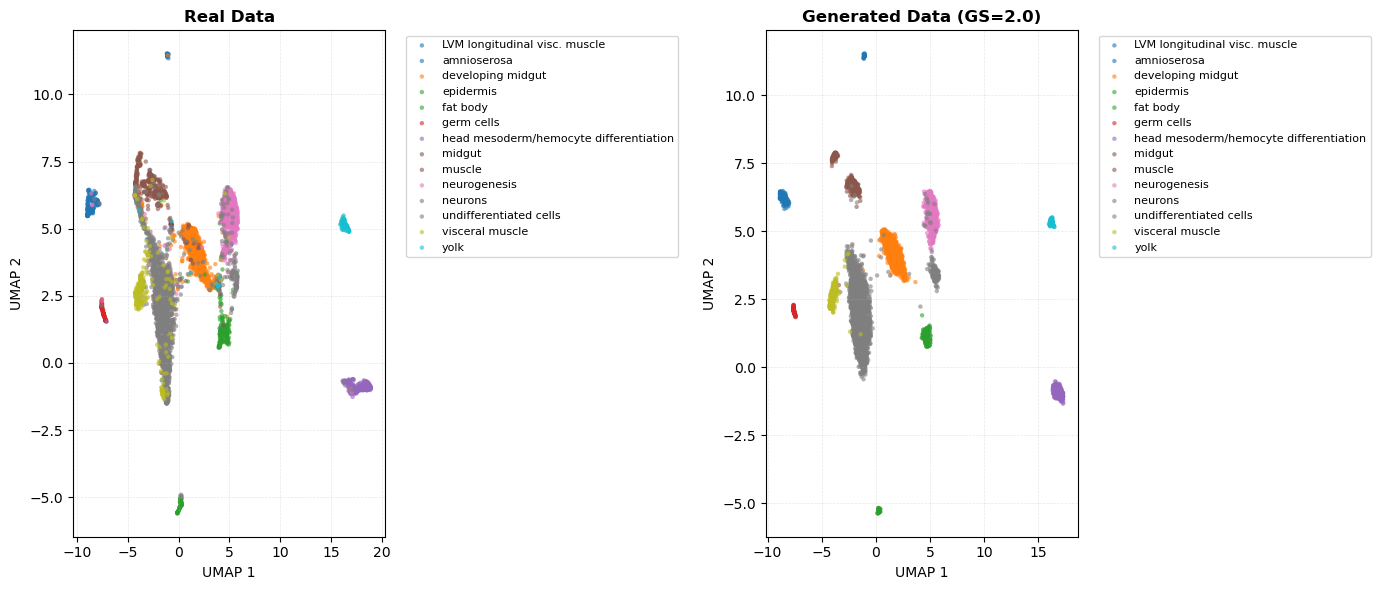

In [6]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
le.fit(latent_adata.obs['cell_type1'])
full_labels = le.transform(latent_adata.obs['cell_type1'])

unique_labels, counts = np.unique(full_labels, return_counts=True)
for label, count in zip(unique_labels, counts):
    print(f"  Class {label}: {count} ({count/len(full_labels)*100:.1f}%)")

device = next(diffusion.parameters()).device
labels_tensor = torch.tensor(full_labels, dtype=torch.long).to(device)

diffusion.eval()
with torch.no_grad():
    latent_samples = diffusion.sample(
        num_samples=len(full_labels),
        labels=labels_tensor,
        guidance_scale=2.0, 
        use_ema=True
    )

print("\n生成数据类别分布:")
unique_gen, counts_gen = np.unique(full_labels, return_counts=True)
for label, count in zip(unique_gen, counts_gen):
    print(f"  Class {label}: {count} ({count/len(full_labels)*100:.1f}%)")


emb1, emb2, fig = compare_umap(
    latent_adata.X, 
    latent_samples.cpu().numpy(),
    labels1=le.inverse_transform(full_labels),  
    labels2=le.inverse_transform(full_labels),
    title1="Real Data",
    title2="Generated Data (GS=2.0)",
    random_state=42
)
